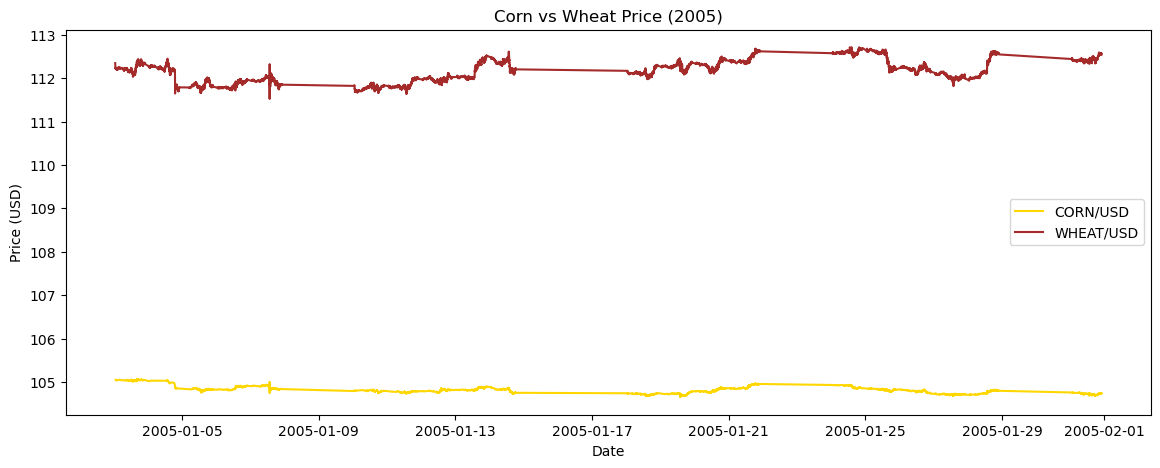

In [ ]:
corn_path = 'dataset/pyfinancialdata/data/cryptocurrencies/kraken/ETH_EUR/2018.csv'
wheat_path = 'dataset/pyfinancialdata/data/cryptocurrencies/kraken/BTC_EUR/2018.csv'
import pandas as pd
import matplotlib.pyplot as plt

corn = pd.read_csv(corn_path, parse_dates=['time'], index_col='time')
wheat = pd.read_csv(wheat_path, parse_dates=['time'], index_col='time')

plt.figure(figsize=(14, 5))
plt.plot(corn['close'], label='CORN/USD', color='gold')
plt.plot(wheat['close'], label='WHEAT/USD', color='brown')
plt.title('Corn vs Wheat Price (2005)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [16]:
import pandas as pd
import os

def aggregate_stock_data(base_path, stock_name):
    all_dfs = []
    
    for year in range(2005, 2021):
        for month in range(1, 13):
            file_path = os.path.join(base_path, stock_name, str(year), f'oanda-{stock_name}-{year}-{month}.csv')
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, parse_dates=['time'])
                all_dfs.append(df)
            else:
                print(f"Missing: {file_path}")
    
    combined = pd.concat(all_dfs).sort_values('time').reset_index(drop=True)
    output_path = f'{stock_name}_2005_2020.csv'
    combined.to_csv(output_path, index=False)
    print(f"Saved {len(combined)} rows to {output_path}")
    return combined

base_path = r'pyfinancialdata/data/currencies/oanda'

corn = aggregate_stock_data(base_path, 'USB02Y_USD')
wheat = aggregate_stock_data(base_path, 'USB10Y_USD')

Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-6.csv
Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-7.csv
Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-8.csv
Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-9.csv
Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-10.csv
Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-11.csv
Missing: pyfinancialdata/data/currencies/oanda\USB02Y_USD\2020\oanda-USB02Y_USD-2020-12.csv
Saved 1163571 rows to USB02Y_USD_2005_2020.csv
Missing: pyfinancialdata/data/currencies/oanda\USB10Y_USD\2020\oanda-USB10Y_USD-2020-6.csv
Missing: pyfinancialdata/data/currencies/oanda\USB10Y_USD\2020\oanda-USB10Y_USD-2020-7.csv
Missing: pyfinancialdata/data/currencies/oanda\USB10Y_USD\2020\oanda-USB10Y_USD-2020-8.csv
Missing: pyfinancialdata/data/currencies

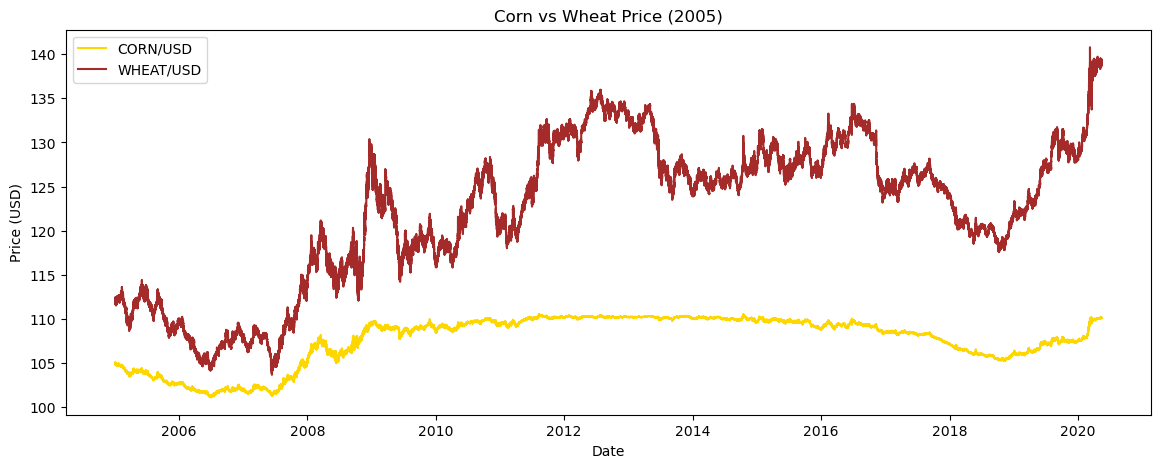

In [18]:
corn_path = 'USB02Y_USD_2005_2020.csv'
wheat_path = 'USB10Y_USD_2005_2020.csv'
import pandas as pd
import matplotlib.pyplot as plt

corn = pd.read_csv(corn_path, parse_dates=['time'], index_col='time')
wheat = pd.read_csv(wheat_path, parse_dates=['time'], index_col='time')

plt.figure(figsize=(14, 5))
plt.plot(corn['close'], label='CORN/USD', color='gold')
plt.plot(wheat['close'], label='WHEAT/USD', color='brown')
plt.title('Corn vs Wheat Price (2005)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [ ]:
corn_dates = set(corn.index)
wheat_dates = set(wheat.index)

only_in_corn = corn_dates - wheat_dates
only_in_wheat = wheat_dates - corn_dates

print(f"Days only in CORN: {len(only_in_corn)}")
print(f"Days only in WHEAT: {len(only_in_wheat)}")
print(f"Days in common: {len(corn_dates & wheat_dates)}")

Days only in CORN: 443778
Days only in WHEAT: 646017
Days in common: 1065270


In [ ]:
print("Missing from WHEAT:", sorted(only_in_corn))
print("Missing from CORN:", sorted(only_in_wheat))

Missing from WHEAT: [datetime.date(2007, 3, 11), datetime.date(2007, 5, 6), datetime.date(2007, 7, 4), datetime.date(2008, 5, 11), datetime.date(2008, 7, 13), datetime.date(2009, 9, 13), datetime.date(2010, 5, 9), datetime.date(2010, 9, 6), datetime.date(2010, 9, 12), datetime.date(2011, 5, 8), datetime.date(2011, 7, 10), datetime.date(2011, 9, 11)]
Missing from CORN: [datetime.date(2006, 5, 7), datetime.date(2009, 7, 12), datetime.date(2012, 5, 27), datetime.date(2012, 9, 2)]


In [ ]:
# only include common columns

import pandas as pd

corn_path = 'CORN_USD_2005_2020.csv'
wheat_path = 'WHEAT_USD_2005_2020.csv'

corn = pd.read_csv(corn_path, parse_dates=['time'], index_col='time')
wheat = pd.read_csv(wheat_path, parse_dates=['time'], index_col='time')

print(f"Before: CORN={len(corn)} rows, WHEAT={len(wheat)} rows")

corn, wheat = corn.align(wheat, join='inner')

corn.dropna(inplace=True)
wheat.dropna(inplace=True)

print(f"After: CORN={len(corn)} rows, WHEAT={len(wheat)} rows")

corn.to_csv(corn_path)
wheat.to_csv(wheat_path)

print("Done, files overwritten.")

Before: CORN=1509048 rows, WHEAT=1711287 rows
After: CORN=1065270 rows, WHEAT=1065270 rows
Done, files overwritten.
